![Gráficas reales](data:image/png;base64)


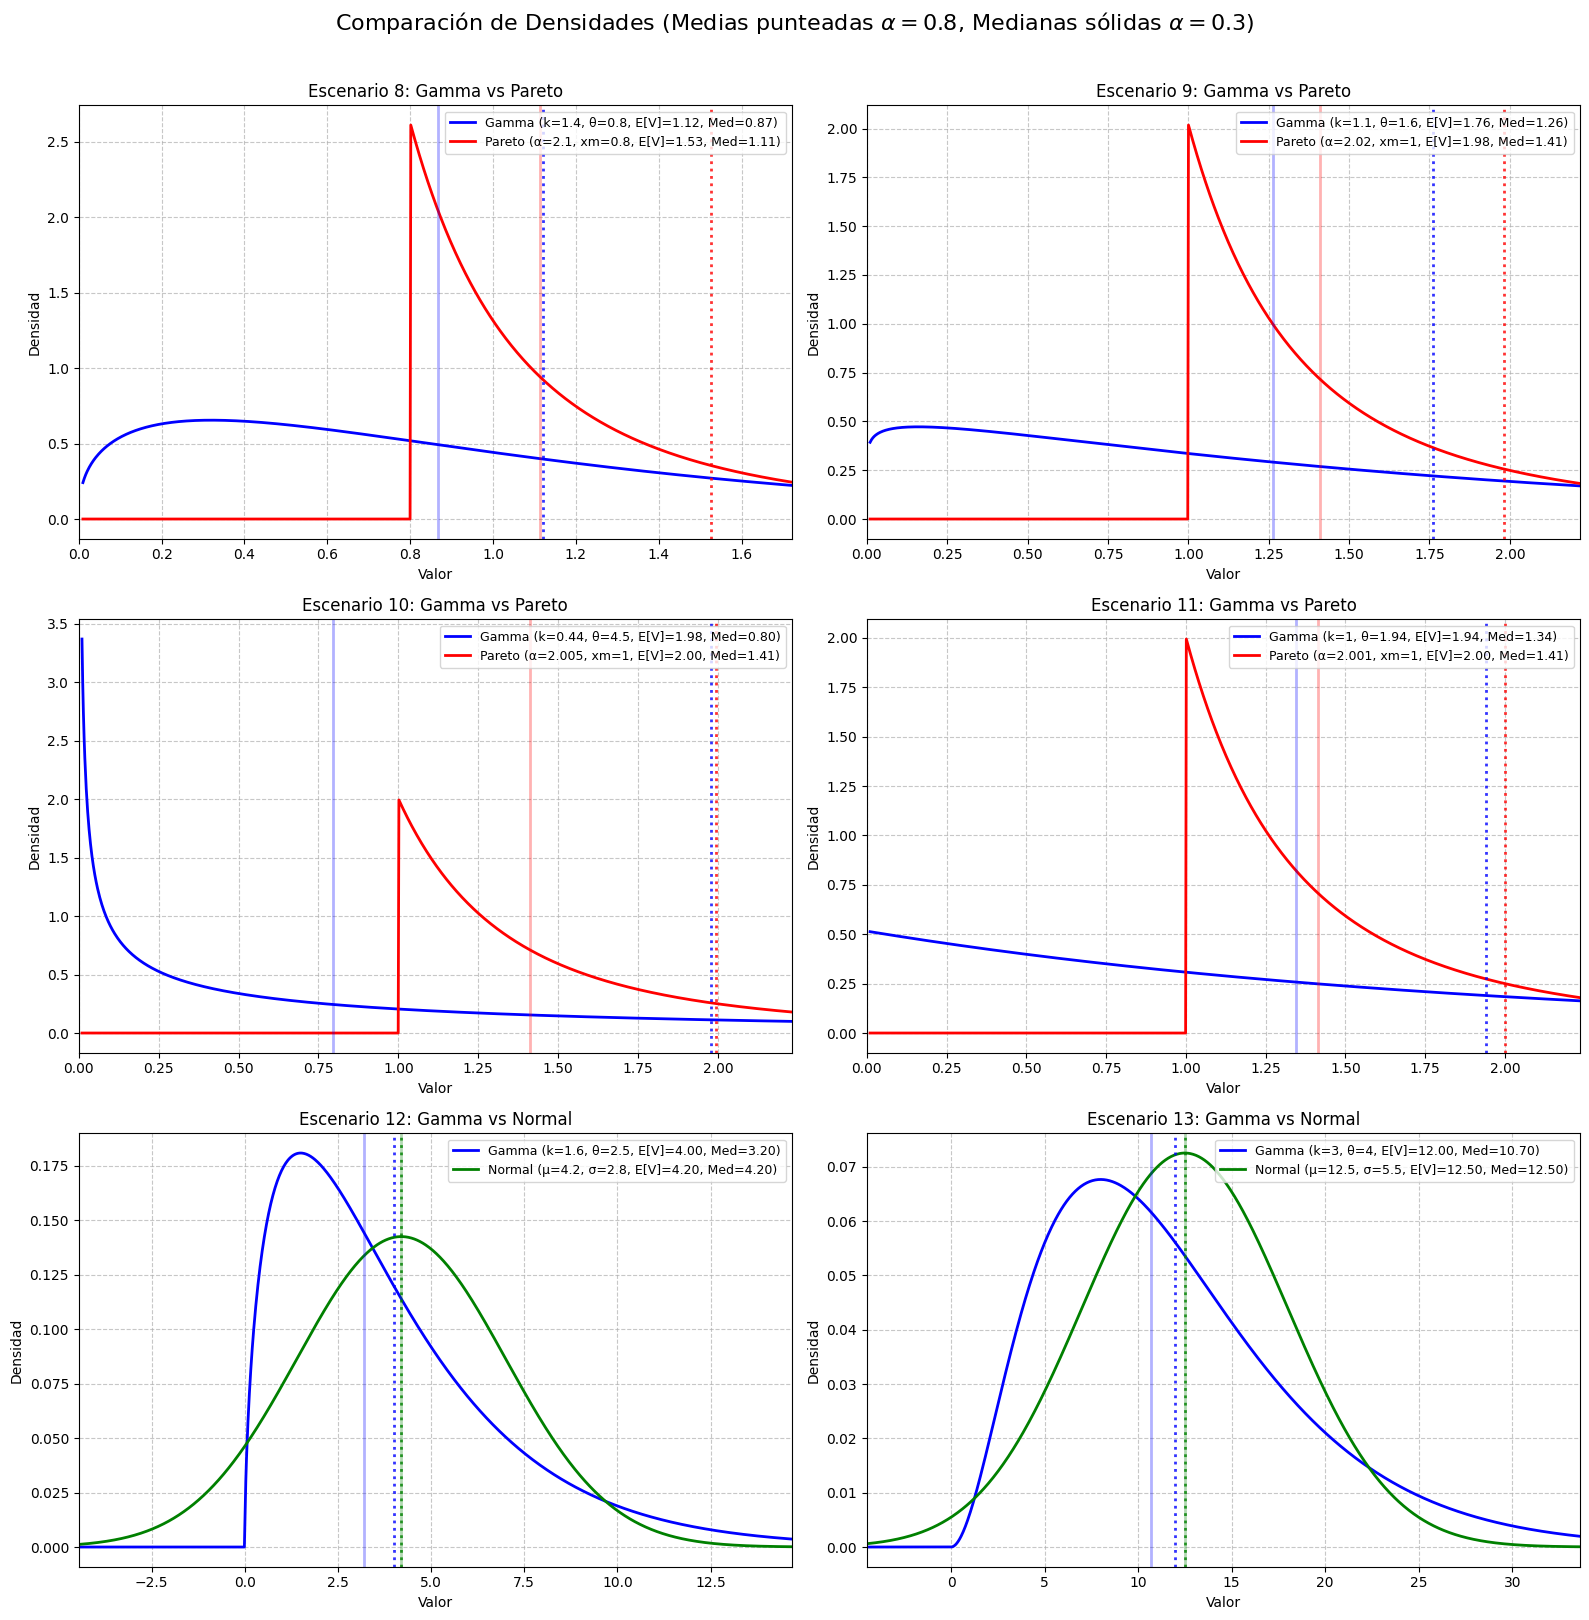

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma, pareto, norm
import io
import base64

def graficar_escenario_pareto(ax, gamma_shape, gamma_scale, pareto_shape, pareto_location, title_suffix):
    x_max = pareto.ppf(0.8, b=pareto_shape, scale=pareto_location)
    x = np.linspace(0.01, x_max, 1000)

    gamma_pdf = gamma.pdf(x, a=gamma_shape, scale=gamma_scale)
    pareto_pdf = pareto.pdf(x, b=pareto_shape, scale=pareto_location)

    gamma_mean = gamma_shape * gamma_scale
    pareto_mean = (pareto_shape * pareto_location) / (pareto_shape - 1)

    gamma_median = gamma.ppf(0.5, a=gamma_shape, scale=gamma_scale)
    pareto_median = pareto.ppf(0.5, b=pareto_shape, scale=pareto_location)

    ax.plot(x, gamma_pdf, color='blue', label=f'Gamma (k={gamma_shape}, θ={gamma_scale}, E[V]={gamma_mean:.2f}, Med={gamma_median:.2f})', linewidth=2)
    ax.plot(x, pareto_pdf, color='red', label=f'Pareto (α={pareto_shape}, xm={pareto_location}, E[V]={pareto_mean:.2f}, Med={pareto_median:.2f})', linewidth=2)

    ax.axvline(gamma_mean, color='blue', linestyle=':', linewidth=2, alpha=0.8)
    ax.axvline(pareto_mean, color='red', linestyle=':', linewidth=2, alpha=0.8)

    ax.axvline(gamma_median, color='blue', linestyle='-', linewidth=2, alpha=0.3)
    ax.axvline(pareto_median, color='red', linestyle='-', linewidth=2, alpha=0.3)

    ax.set_title(f'Escenario {title_suffix}: Gamma vs Pareto', fontsize=12)
    ax.set_xlabel('Valor', fontsize=10)
    ax.set_ylabel('Densidad', fontsize=10)
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.set_xlim(0, x_max)

def graficar_escenario_normal(ax, gamma_shape, gamma_scale, norm_mean, norm_sd, title_suffix):
    x_min = min(0, norm.ppf(0.001, loc=norm_mean, scale=norm_sd))
    x_max = max(gamma.ppf(0.99, a=gamma_shape, scale=gamma_scale), norm.ppf(0.99, loc=norm_mean, scale=norm_sd))
    x = np.linspace(x_min, x_max, 1000)

    gamma_pdf = gamma.pdf(x, a=gamma_shape, scale=gamma_scale)
    norm_pdf = norm.pdf(x, loc=norm_mean, scale=norm_sd)

    gamma_mean = gamma_shape * gamma_scale
    gamma_median = gamma.ppf(0.5, a=gamma_shape, scale=gamma_scale)

    ax.plot(x, gamma_pdf, color='blue', label=f'Gamma (k={gamma_shape}, θ={gamma_scale}, E[V]={gamma_mean:.2f}, Med={gamma_median:.2f})', linewidth=2)
    ax.plot(x, norm_pdf, color='green', label=f'Normal (μ={norm_mean}, σ={norm_sd}, E[V]={norm_mean:.2f}, Med={norm_mean:.2f})', linewidth=2)

    ax.axvline(gamma_mean, color='blue', linestyle=':', linewidth=2, alpha=0.8)
    ax.axvline(norm_mean, color='green', linestyle=':', linewidth=2, alpha=0.8)

    ax.axvline(gamma_median, color='blue', linestyle='-', linewidth=2, alpha=0.3)
    ax.axvline(norm_mean, color='green', linestyle='-', linewidth=2, alpha=0.3)

    ax.set_title(f'Escenario {title_suffix}: Gamma vs Normal', fontsize=12)
    ax.set_xlabel('Valor', fontsize=10)
    ax.set_ylabel('Densidad', fontsize=10)
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.set_xlim(x_min, x_max)

fig, axs = plt.subplots(3, 2, figsize=(16, 17))
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()

graficar_escenario_pareto(ax1, 1.4, 0.8, 2.1, 0.8, '8')
graficar_escenario_pareto(ax2, 1.1, 1.6, 2.02, 1, '9')
graficar_escenario_pareto(ax3, 0.44, 4.5, 2.005, 1, '10')
graficar_escenario_pareto(ax4, 1, 1.94, 2.001, 1, '11')
graficar_escenario_normal(ax5, 1.6, 2.5, 4.2, 2.8, '12')
graficar_escenario_normal(ax6, 3, 4, 12.5, 5.5, '13')

fig.suptitle('Comparación de Densidades (Medias punteadas $\\alpha=0.8$, Medianas sólidas $\\alpha=0.3$)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.97])

buf = io.BytesIO()
plt.savefig(buf, format='png')
buf.seek(0)
img_base64 = base64.b64encode(buf.read()).decode('utf-8')
print(f"![Gráficas reales](data:image/png;base64)")